# MFE 230X Final Project, Part 1: Speed

Based on Scholtus and van Dijk (2012), *High-Frequency Technical Trading: The Importance of Speed*, and on the instructions of Discussion Session 06.

| Choice | Value |
|---|---|
| Liquid equity | AAPL (Nasdaq) |
| Less liquid equity | GPRO (Nasdaq) |
| FX pair | EUR/USD |
| Period | September 2019, 20 trading days (3 to 30 September) |
| Signals from the paper | Moving average (MA), on-balance volume (OBV) |
| Own signal | Persistent best-quote imbalance (IMB) |
| Execution delays | 0 ms, 100 ms, 1 second |
| Book | $1,000,000 |
| Rule universe for Figures 6 and 7 | 601 rules per asset (288 MA, 288 OBV, 25 IMB) |

3 assets x 3 signals x 3 delays = **27 profit-and-loss reports** (section 3). The assignment counts 18: three assets, the two signals taken from the paper, three delays. Our own signal adds 9.

**Trading procedure.**

- A signal in {-1, 0, +1} is built every 60 seconds from the information available at the interval change.
- The order it implies is executed `delay` later against the best quote prevailing at that moment: buys pay the ask, sells receive the bid. The bid-ask spread is the only transaction cost.
- Signals are acted upon from 09:40 to 15:50 New York time only; the book is closed every day at the 15:50:00 price.
- Every trade is for the number of units worth $1,000,000 on the asset's first day (4,850 AAPL shares, 263,505 GPRO shares, EUR 913,013).
- The total return of a strategy is the sum of the simple percentage returns of its round trips (paper eq. 1 and 2), not compounded. The dollar P&L is the same sum valued on the fixed number of units.

**Main results.**

1. **All 27 strategies lose money once the spread is paid**, from -0.19% (EUR/USD, MA) to -109% (GPRO, IMB). On GPRO the three signals earn money at the mid, and the 22.5 bps spread takes it all back.
2. **For one strategy over one month the cost of delay is too small to measure.** Averaged over the nine asset/signal pairs it is +0.02% at 100 ms and -0.12% at 1 second, with a 90% interval of -0.42% to +0.14%.
3. **Pooling the orders of a 601-rule universe makes it measurable, at 1 second and not at 100 ms.** Executing 1 second late costs 0.07 bps per order for MA rules on AAPL, 0.06 bps for MA rules on GPRO and 0.11 bps for IMB rules on GPRO. At 100 ms every effect is within 0.02 bps.
4. **The paper's central result holds on the liquid stock, after its selection-bias test.** On AAPL, delay lowers the return of profitable rules by 0.7% at 200 ms and 3.1% at 1 second, more than random rules lose (p = 0.03 and p < 0.001). On GPRO and EUR/USD the losses at 1 second (-1.0% and -1.2%) are what selection alone produces.
5. **Tick frequency sets how often a delayed order meets a different quote** (62% of the time after 1 second on AAPL, 55% on EUR/USD, 1% on GPRO); **tick size relative to price sets how much each miss costs** (22 bps on GPRO). Sensitivity to delay is the product of the two.
6. **A $1,000,000 order fills at the best quote only on EUR/USD**: it is half the displayed size there, 22 times the displayed size on AAPL and 53 times on GPRO.

All the logic lives in `src/speed.py`; this notebook runs it and reports the results.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "src")
import speed

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
OUT = Path("outputs"); FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)

ASSETS = ["AAPL", "GPRO", "EURUSD"]
SIGNALS = ["MA", "OBV", "IMB"]
ASSET_COLOR = {"AAPL": "#2a78d6", "GPRO": "#eb6834", "EURUSD": "#1baf7a"}   # identity
SIGNAL_COLOR = {"MA": "#2a78d6", "OBV": "#eb6834", "IMB": "#1baf7a"}                    # identity
DELAY_COLOR = {0: "#86b6ef", 100: "#2a78d6", 1000: "#0d366b"}                # magnitude: one hue, light to dark
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})
RING = dict(ls="", marker="o", ms=11, mfc="none", mec=INK, mew=1.2)

In [2]:
%%time
run = speed.run_all(ASSETS)
base, micro = speed.baseline_frame(run), run.micro
base.to_csv(OUT / "daily_results_baseline.csv", index=False)
speed.universe_frame(run).to_csv(OUT / "daily_returns_universe.csv.gz", index=False, float_format="%.8g")
print(run.rules.groupby(["kind", "family"], sort=False).size().to_dict())
print({a: len(d) for a, d in run.dates.items()}, "trading days")

{('baseline', 'MA'): 1, ('baseline', 'OBV'): 1, ('baseline', 'IMB'): 1, ('universe', 'MA'): 288, ('universe', 'OBV'): 288, ('universe', 'IMB'): 25}
{'AAPL': 20, 'GPRO': 20, 'EURUSD': 20} trading days
CPU times: user 18.3 s, sys: 1.52 s, total: 19.8 s
Wall time: 20.1 s


## 1. Data, liquidity and tick frequency

- **Equities.** Databento Nasdaq TotalView-ITCH, MBP-1 schema: every trade and every change of the best bid and offer, nanosecond stamps. Session 09:30 to 16:00 New York time (13:30 to 20:00 UTC).
- **EUR/USD.** Dukascopy tick data: every change of the best bid/ask with the quoted sizes, millisecond stamps (`src/download_fx.py`). The discussion session points to a currency file on the MFE-4 server; we use a public source so that the FX leg covers the same month, the same 20 days and the same 13:30 to 20:00 UTC window as the equities. The three assets then face the same clock and the same number of signals.

Limits of the data:

1. **Top of book only.** The paper and the discussion session use a price-impact price, the average price paid when the order walks the book. MBP-1 has no depth, so every order is assumed to fill in full at the best quote. The second table below measures how strong that assumption is.
2. **No FX trade tape.** For EUR/USD the volume input of OBV is tick volume: one unit for each quote that moves the mid.
3. **One FX venue.** Dukascopy is one venue's feed, so its tick frequency understates the whole EUR/USD market.

In [3]:
liq = micro.groupby("asset", sort=False).mean(numeric_only=True)
table1 = pd.DataFrame({
    "Mid price": liq.mid,
    "Quoted spread (bps)": liq.spread_bps,
    "Quoted spread (price units)": liq.spread_ticks,
    "Depth at best (units)": liq.depth,
    "BBO updates per second": liq.bbo_updates_per_s,
    "Quote price changes per second": liq.quote_moves_per_s,
    "Trades per second": liq.trades_per_s,
    "1-minute volatility (bps)": liq.vol_1min_bps,
    "P(quote changes within 100 ms)": liq.p_quote_change_100ms,
    "P(quote changes within 1 s)": liq.p_quote_change_1000ms,
    "Mean |mid move| after 100 ms (bps)": liq.abs_mid_move_100ms_bps,
    "Mean |mid move| after 1 s (bps)": liq.abs_mid_move_1000ms_bps,
}).T[ASSETS]
table1.loc["Trades per second", "EURUSD"] = np.nan   # no FX trade tape: the OBV input there is tick volume
table1.loc["Depth at best (units)", "EURUSD"] *= 1e6   # Dukascopy quotes sizes in millions of euros
table1.to_csv(OUT / "table1_liquidity_tick_frequency.csv")
table1.style.format("{:,.4f}", na_rep="n/a")

asset,AAPL,GPRO,EURUSD
Mid price,217.8983,4.5095,1.1011
Quoted spread (bps),0.7335,22.5184,0.2703
Quoted spread (price units),0.0160,0.0101,0.0000
Depth at best (units),225.3725,"4,944.7814","1,673,821.9662"
BBO updates per second,40.0641,1.7673,1.4444
Quote price changes per second,8.7970,0.0399,1.2063
Trades per second,3.4544,0.1148,n/a
1-minute volatility (bps),5.3174,16.9705,1.1432
P(quote changes within 100 ms),0.2555,0.0023,0.1496
P(quote changes within 1 s),0.6218,0.0113,0.5503


In [4]:
cap = speed.capacity_table(run).reindex(ASSETS)
cap.to_csv(OUT / "table1b_order_size_vs_displayed_size.csv")
cap.style.format("{:,.0f}").format("{:,.1f}", subset=["Order / displayed size"])

,Units per order,Displayed size at the best quote (units),Displayed size ($),Order / displayed size
asset,,,,
AAPL,"4,850",225,"49,108",21.5
GPRO,"263,505","4,945","22,299",53.3
EURUSD,"913,013","1,673,822","1,843,067",0.5


**Reading the two tables.** The three assets differ on three separate dimensions.

- *Cost of trading.* EUR/USD is the cheapest (0.27 bps quoted spread), AAPL close behind (0.73 bps), GPRO about 30 times more expensive than AAPL (22.5 bps). GPRO trades near $4.50, so the one-cent minimum tick alone is 22 bps of the price: its spread is pinned at one tick.
- *Tick frequency.* AAPL's best quote changes price 8.8 times per second, EUR/USD 1.2 times, GPRO once every 25 seconds. The quote a delayed order meets differs from the one the signal saw 62% of the time after 1 second on AAPL, 55% on EUR/USD and 1.1% on GPRO.
- *Size available.* The $1,000,000 order is 22 times the size displayed at the best quote on AAPL and 53 times on GPRO, but only half of it on EUR/USD. Filling at the best quote is realistic for the currency pair and optimistic for the two stocks. Returns in percent do not depend on the size under this assumption, so they correspond to the paper's smallest capacity level; the dollar figures scale them to $1,000,000.

## 2. The three signals

Inputs are sampled at each one-minute interval change $t$: the mid quote $m_t$, the on-balance volume $obv_t$ and the imbalance $I_t$. With $ma_t(n, x)$ the average of the last $n$ values of $x$:

**MA (paper eq. 3).** Long if $ma_t(s,m) > (1+b)\,ma_t(l,m)$, short if $ma_t(s,m) < (1-b)\,ma_t(l,m)$, flat otherwise. Baseline $s=5$, $l=30$, $b=0.0005$ (5 bps, the smallest non-zero band in the paper's grid, so that the rule also trades on EUR/USD).

**OBV (paper eq. 6).** $obv_t$ is the running sum since the open of trade volume signed by the tick rule, auction crosses excluded. Long if $ma_t(s,obv) > ma_t(l,obv) + band$, short if $ma_t(s,obv) < ma_t(l,obv) - band$. Baseline $s=5$, $l=30$, $b=0.5$. Two departures from the paper:

- *Sign.* Volume is added on an uptick and subtracted on a downtick, the standard on-balance-volume convention. The equation as printed in the paper has the opposite sign.
- *Band.* The paper's band is proportional to the level of OBV. Because OBV restarts at zero every day and changes sign, the band here is $b$ times the average one-minute volume over the long window.

**IMB (own signal): persistent best-quote imbalance.** At every instant the queue imbalance is $(q^{bid}-q^{ask})/(q^{bid}+q^{ask})$ with $q$ the size at the best bid and ask. $I_t$ is its time-weighted average over the minute ending at $t$. Long if $I > \theta$ in each of the last $k$ minutes, short if $I < -\theta$ in each of them, flat otherwise. Baseline $k=2$, $\theta=0.3$. The idea: a queue that stays heavier on the bid for whole minutes signals buying pressure that has not yet moved the price; requiring persistence filters the flickering that dominates instantaneous imbalance.

**Parameters.** The baseline lookbacks and bandwidths are values of the paper's 60-second settings (Appendix A). The same parameters are used for the three assets and were not tuned to improve the P&L.

**Start of trading.** Lookback windows start at the 09:30 open. A rule with a 30-minute lookback (the baseline MA and OBV) therefore gives its first signal at 10:00, and IMB at 09:40. The paper warms its rules up on pre-market quotes; we do not, because GPRO's pre-market book is too thin to give a meaningful mid.

**Rule universe.** For the Figure 6 and 7 analysis the two paper families use every combination of the paper's 60-second grid: 48 pairs $(s, l)$ with $s \in \{2, 5, 10, 15, 20, 25, 30\}$, $l \in \{10, 15, \dots, 45, 60\}$, $s < l$, times 6 bands, with the paper's two universal filters at their neutral values (no confirmation delay, no minimum holding period). That is 288 MA rules ($b$ from 0 to 40 bps) and 288 OBV rules ($b$ from 0 to 1.5). IMB adds 25 rules ($k = 1, \dots, 5$; $\theta = 0.1, \dots, 0.5$). Total: 601 rules per asset, listed in `speed.UNIVERSE`.

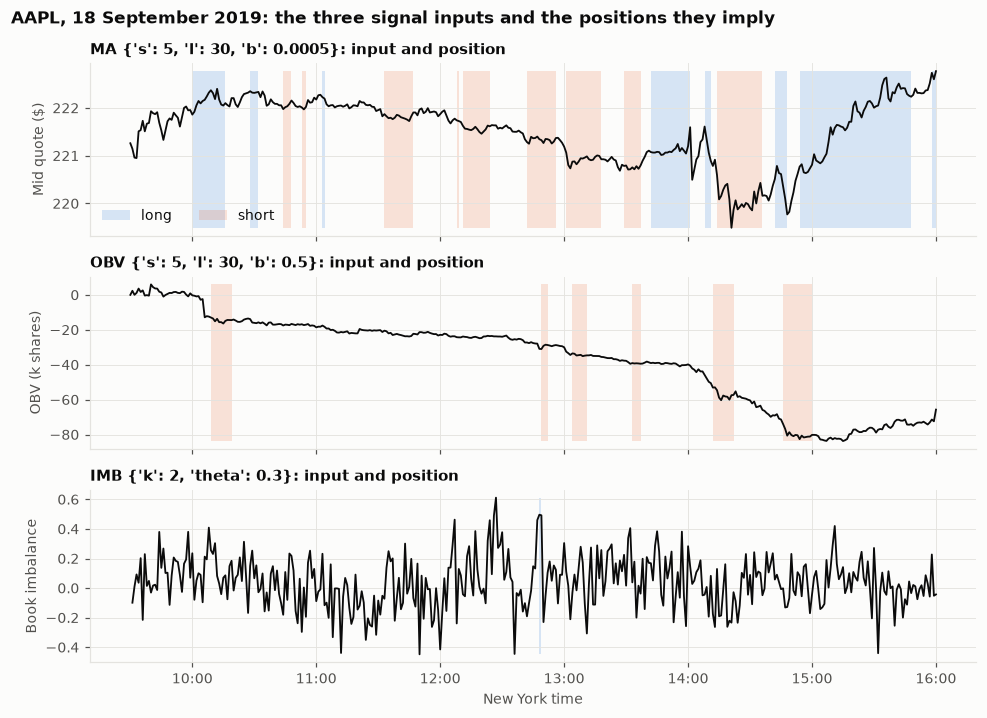

In [5]:
day = speed.load_equity_day("20190918")["AAPL"]      # FOMC day
f = speed.features(day)
t = pd.to_datetime(f["grid"]).tz_localize("UTC").tz_convert("America/New_York").tz_localize(None)
fig, axes = plt.subplots(3, 1, figsize=(9, 6.6), sharex=True)
panels = [("MA", f["mid"], "Mid quote ($)"), ("OBV", f["obv"] / 1e3, "OBV (k shares)"),
          ("IMB", f["imb"], "Book imbalance")]
for ax, (name, y, lab) in zip(axes, panels):
    fn, prm = speed.BASELINE[name]
    sig = fn(f, **prm)
    ax.plot(t, y, color=INK, lw=1.2)
    lo, hi = np.nanmin(y), np.nanmax(y)
    ax.fill_between(t, lo, hi, where=sig == 1, color="#2a78d6", alpha=0.18, lw=0, step="post", label="long")
    ax.fill_between(t, lo, hi, where=sig == -1, color="#eb6834", alpha=0.18, lw=0, step="post", label="short")
    ax.set_title(f"{name} {prm}: input and position", loc="left"); ax.set_ylabel(lab)
axes[0].legend(loc="lower left", ncol=2)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); axes[-1].set_xlabel("New York time")
fig.suptitle("AAPL, 18 September 2019: the three signal inputs and the positions they imply", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "01_signals_example_day.png"); plt.show()

## 3. The 27 profit-and-loss reports

One line per asset / signal / delay: the 18 reports of the two paper signals and the 9 of our own.

- *P&L* and *Final book* are in dollars for the fixed number of units.
- *Total return* is the sum of the simple round-trip returns.
- *P&L at mid* values the same trades at the mid quote, so *Spread paid* = P&L at mid - P&L is what crossing the spread cost.

In [6]:
rep = speed.pnl_report(base)
rep.to_csv(OUT / "table2_pnl_reports_27.csv", index=False)
print("Units traded per signal ($1,000,000 at the first day's 09:40 mid):", {a: round(float(run.units[a]), 1) for a in ASSETS})
cols = {"pnl": "P&L ($)", "final_book": "Final book ($)", "total_return_pct": "Total return (%)",
        "pnl_mid": "P&L at mid ($)", "spread_paid": "Spread paid ($)", "round_trips": "Round trips",
        "bps_per_trip": "Net bps / trip", "win_rate_pct": "Win rate (%)",
        "best_day": "Best day ($)", "worst_day": "Worst day ($)", "daily_std": "Daily std ($)"}
show = rep.rename(columns={"asset": "Asset", "family": "Signal", "delay_ms": "Delay (ms)", **cols})
show = show.set_index(["Asset", "Signal", "Delay (ms)"])[list(cols.values())]
print(len(show), "profit-and-loss reports")
show.style.format("{:,.0f}").format("{:,.2f}", subset=["Total return (%)", "Net bps / trip", "Win rate (%)"])

Units traded per signal ($1,000,000 at the first day's 09:40 mid): {'AAPL': 4849.9, 'GPRO': 263504.6, 'EURUSD': 913012.7}
27 profit-and-loss reports


In [7]:
tot = rep.pivot_table(index="delay_ms", columns=["asset", "family"], values="total_return_pct", sort=False)
tot.index = tot.index / 1000; tot.index.name = "Delay (s)"
tot.to_csv(OUT / "table2b_total_return_by_delay.csv")
print("Total return (%) by delay")
tot.style.format("{:,.3f}")

Total return (%) by delay


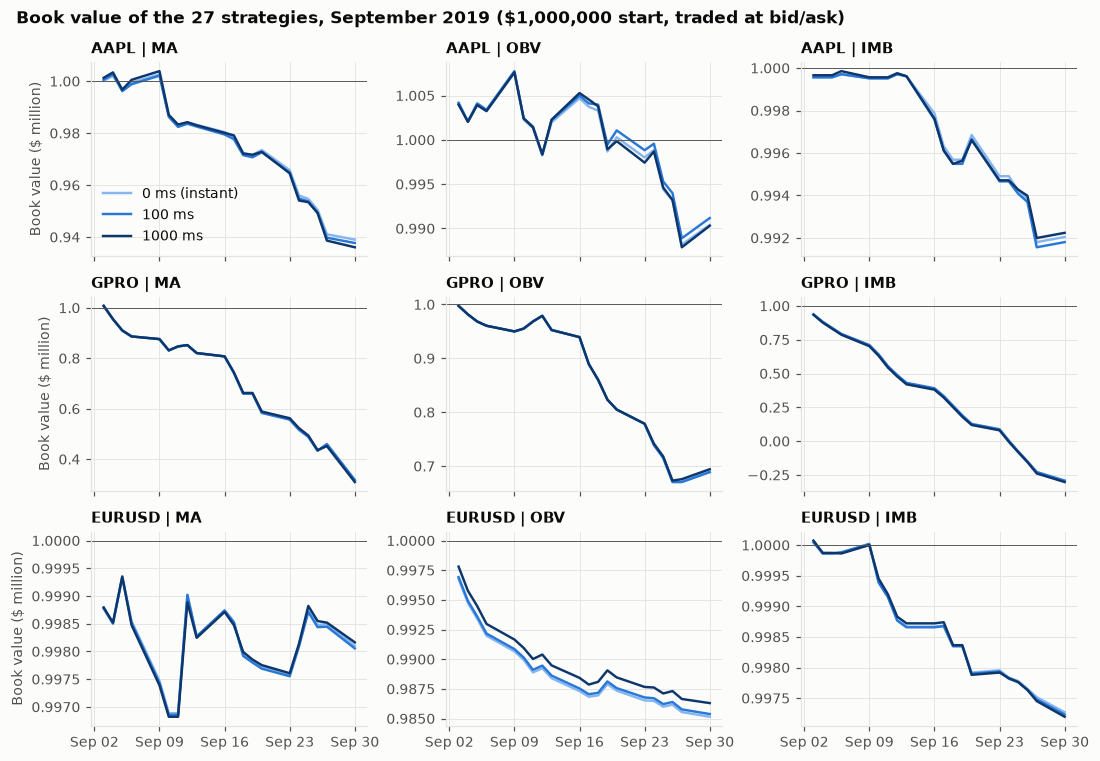

In [8]:
b = base[base.delay_ms.isin(speed.DELAYS_MS)]
fig, axes = plt.subplots(3, 3, figsize=(10, 7), sharex=True)
for i, a in enumerate(ASSETS):
    for j, s in enumerate(SIGNALS):
        ax = axes[i, j]
        for d in speed.DELAYS_MS:
            x = b[(b.asset == a) & (b.family == s) & (b.delay_ms == d)].sort_values("date")
            ax.plot(x.date, speed.BOOK / 1e6 + x.pnl.cumsum() / 1e6, color=DELAY_COLOR[d], lw=1.6,
                    label=f"{d} ms" if d else "0 ms (instant)")
        ax.axhline(1, color=MUTED, lw=0.6)
        ax.set_title(f"{a} | {s}", loc="left")
        if j == 0: ax.set_ylabel("Book value ($ million)")
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0, 0].legend(loc="lower left")
fig.suptitle("Book value of the 27 strategies, September 2019 ($1,000,000 start, traded at bid/ask)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "02_book_value_27_strategies.png"); plt.show()

### Holding times

Number of long and short positions over the month and their average length, with instantaneous execution.

In [9]:
hold = speed.holding_report(base)
hold.to_csv(OUT / "table2c_holding_periods.csv")
hold.T.style.format("{:,.2f}")

**What the reports show.**

- **Every strategy loses money net of the spread.** Total returns range from -0.19% (EUR/USD, MA, 56 round trips) to -109% (GPRO, IMB, 618 round trips). A book below zero is possible because the same number of units is traded on every signal without compounding: 618 round trips at about 18 bps each cost more than the book.
- **On GPRO the loss is the spread.** Valued at the mid, the three GPRO strategies make money (+$108,037 for MA, +$84,321 for OBV, +$339,921 for IMB). The spread paid is $0.4 to 1.6 million. The signals predict the direction of the next move, but not by the 22.5 bps a round trip costs.
- **On AAPL the signal itself loses.** AAPL MA loses $37,878 at the mid out of $60,963 in total: a trend rule on one-minute mids buys after the rise and the price partly reverts. The spread is a secondary cost there.
- **Holding times.** MA positions last 9 to 20 minutes on average, OBV positions 9 to 13 minutes, IMB positions 1 to 4 minutes. MA trades about 300 times on each stock and 56 times on EUR/USD, whose one-minute volatility (1.1 bps) rarely carries the short average 5 bps away from the long one. IMB trades far more on GPRO (618 round trips) than on AAPL (42) or EUR/USD (53): GPRO's queues are large and persistently one-sided.
- **The delay lines are almost on top of each other.** Within each panel the three delays differ by far less than the strategy loses. Section 4 measures that difference.

## 4. Cost of delay of the nine baseline strategies

Cost of delay = total return with the delay - total return with instantaneous execution, for the same signal, in percentage points. **Negative means the delay hurts.** Two measures of uncertainty are given: the Wilcoxon signed-rank test on the 20 daily differences, which is the paper's test (not reported when fewer than 6 days differ), and a 90% interval obtained by resampling the 20 trading days 5,000 times. The figure extends the two required delays to the range 0 to 1,000 ms; the third table measures the same cost order by order (defined in section 5).

In [10]:
cod = speed.cost_of_delay(base)
cod.to_csv(OUT / "table3_cost_of_delay_baseline.csv", index=False)
cod.rename(columns={"asset": "Asset", "family": "Signal", "delay_ms": "Delay (ms)", "return_0ms_pct": "Return 0 ms (%)",
                    "return_delayed_pct": "Return delayed (%)", "cost_pct": "Cost of delay (%)", "ci_lo_pct": "90% CI low",
                    "ci_hi_pct": "90% CI high", "cost_usd": "Cost of delay ($)", "cost_bps_per_trip": "Cost (bps / trip)",
                    "days_worse": "Days worse", "days_better": "Days better", "wilcoxon_p": "Wilcoxon p"}
           ).set_index(["Asset", "Signal", "Delay (ms)"]).style.format("{:,.3f}", na_rep="n/a").format(
    "{:,.0f}", subset=["Cost of delay ($)", "Days worse", "Days better"])

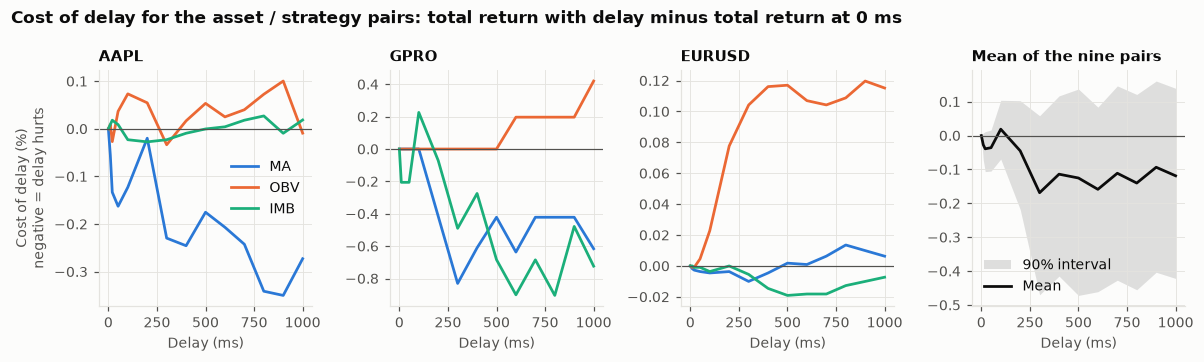

delay_ms,100,1000
AAPL | MA,-0.123,-0.273
AAPL | OBV,0.073,-0.009
AAPL | IMB,-0.023,0.019
GPRO | MA,0.000,-0.616
GPRO | OBV,0.000,0.420
GPRO | IMB,0.226,-0.724
EURUSD | MA,-0.005,0.006
EURUSD | OBV,0.023,0.115
EURUSD | IMB,-0.004,-0.007
Mean,0.019,-0.119


In [11]:
curve = speed.delay_curve(base)
curve.to_csv(OUT / "table3b_cost_of_delay_curve.csv")
fig, axes = plt.subplots(1, 4, figsize=(11, 3.3))
for ax, a in zip(axes, ASSETS):
    for s in SIGNALS:
        ax.plot(curve.index, curve[f"{a} | {s}"], color=SIGNAL_COLOR[s], lw=1.8, label=s)
    ax.set_title(a, loc="left")
axes[3].fill_between(curve.index, curve["Mean lo"], curve["Mean hi"], color=INK, alpha=0.12, lw=0, label="90% interval")
axes[3].plot(curve.index, curve["Mean"], color=INK, lw=1.8, label="Mean")
axes[3].set_title("Mean of the nine pairs", loc="left"); axes[3].legend(loc="lower left")
for ax in axes:
    ax.axhline(0, color=MUTED, lw=0.8); ax.set_xlabel("Delay (ms)")
axes[0].set_ylabel("Cost of delay (%)\nnegative = delay hurts"); axes[0].legend()
fig.suptitle("Cost of delay for the asset / strategy pairs: total return with delay minus total return at 0 ms", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "03_cost_of_delay_curve.png"); plt.show()
curve.loc[[100, 1000]].T.style.format("{:,.3f}")

In [12]:
ORDER_COLS = {"asset": "Asset", "family": "Signal", "horizon_ms": "Delay (ms)", "orders": "Orders",
              "effect_bps": "Effect per order (bps)", "ci_lo": "90% CI low", "ci_hi": "90% CI high", "p_two_sided": "p (two-sided)"}
oe = speed.order_effect_table(run, "baseline")
oe.to_csv(OUT / "table3c_effect_per_order_baseline.csv", index=False)
oe.rename(columns=ORDER_COLS).set_index(["Asset", "Signal", "Delay (ms)"]).style.format("{:,.4f}").format("{:,.0f}", subset=["Orders"])

**Baseline strategies.**

- **At 100 ms the cost is within 0.23 percentage points for all nine pairs**, with no consistent sign: negative for AAPL MA (-0.12%), positive for GPRO IMB (+0.23%) and AAPL OBV (+0.07%), zero for GPRO MA and OBV, whose execution prices almost never change within 100 ms. The mean over the nine pairs is +0.02%.
- **At 1 second the less liquid stock pays the most.** GPRO IMB loses 0.72 percentage points and GPRO MA 0.62 (-$7,905 each). AAPL MA loses 0.27 (-$2,958) and EUR/USD MA is unchanged (+0.01, +$64).
- **The OBV strategies gain from delay** at 1 second on GPRO (+0.42%) and EUR/USD (+0.12%).
- **The mean curve is negative at every delay from 200 ms**, between -0.05% and -0.17%, and stands at -0.12% at 1 second. This is the shape of the discussion-session example: a small, noisy effect at short delays, a steady cost at longer ones.
- **None of this is statistically distinguishable from zero.** The 90% interval of the mean is -0.42% to +0.14% at 1 second, and every 1-second interval in the table contains zero or touches it. The only intervals that exclude zero are three small effects at 100 ms (AAPL OBV +0.07%, EUR/USD OBV +0.02%, EUR/USD IMB -0.004%). On GPRO a single one-cent difference on one execution moves the total return by 0.22%.

One strategy over one month places 84 to 1,236 orders. That is not enough to measure an effect of a few hundredths of a basis point per order, which is why the paper works with thousands of rules. The rest of the analysis does the same.

## 5. Importance of speed over a 601-rule universe

### All rules (Figure 6 of the paper)

As in the paper, each day the average return across rules with delay $d$ is compared with the average under instantaneous execution, in percent of the latter, and the daily figures are averaged over the 20 days (solid line). Negative means delay lowers performance. Rules with a zero return on a day are excluded; on an average day 414 rules trade on AAPL, 547 on GPRO and 303 on EUR/USD. The dashed line is the median of the same daily figures, and the table adds the difference in return terms (bps per rule-day), which does not depend on a ratio.

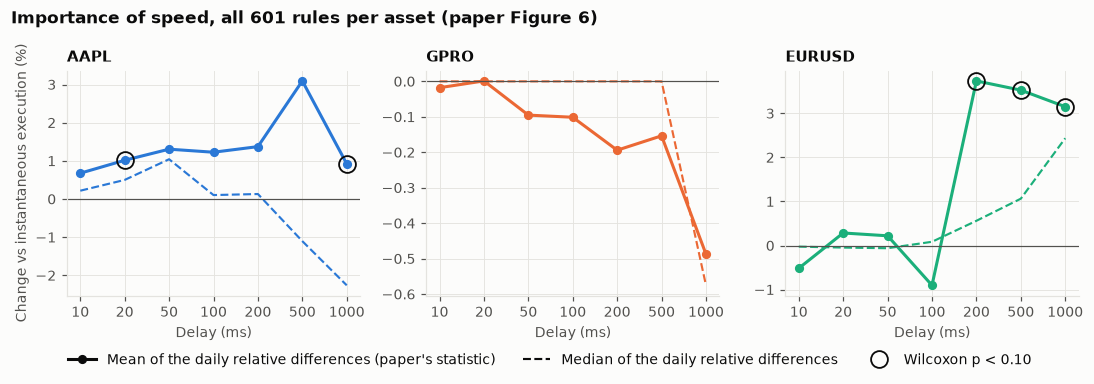

In [13]:
ios = {k: speed.importance_of_speed(run, k) for k in ("all", "positive", "negative")}
pd.concat(ios.values(), ignore_index=True).to_csv(OUT / "table4_importance_of_speed.csv", index=False)
tab = ios["all"]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, a in zip(axes, ASSETS):
    x = tab[tab.asset == a]
    pos = np.arange(len(x))
    ax.plot(pos, x.importance_pct, color=ASSET_COLOR[a], marker="o", ms=5)
    ax.plot(pos, x.median_pct, color=ASSET_COLOR[a], ls="--", lw=1.4)
    sig = x.wilcoxon_p.to_numpy() < 0.10
    ax.plot(pos[sig], x.importance_pct.to_numpy()[sig], **RING)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_xticks(pos); ax.set_xticklabels(x.delay_ms); ax.set_xlabel("Delay (ms)")
    ax.set_title(a, loc="left")
axes[0].set_ylabel("Change vs instantaneous execution (%)")
handles = [plt.Line2D([], [], color=INK, marker="o", ms=5), plt.Line2D([], [], color=INK, ls="--", lw=1.4), plt.Line2D([], [], **RING)]
fig.legend(handles, ["Mean of the daily relative differences (paper's statistic)", "Median of the daily relative differences", "Wilcoxon p < 0.10"],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.07))
fig.suptitle("Importance of speed, all 601 rules per asset (paper Figure 6)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "04_importance_of_speed_all.png"); plt.show()
tab[tab.delay_ms.isin([100, 1000])].set_index(["asset", "delay_ms"])[
    ["importance_pct", "median_pct", "pooled_pct", "diff_bps_per_day", "rules_per_day", "wilcoxon_p"]].style.format("{:,.3f}")

**Reading Figure 6.**

- **At 100 ms nothing is distinguishable from zero** on any asset.
- **GPRO declines with delay**: -0.10% at 100 ms and -0.49% at 1 second, or 0.86 bps per rule-day (Wilcoxon p = 0.11).
- **AAPL loses at 1 second, but the paper's statistic hides it.** The mean of daily ratios is positive (+0.9% at 1 second) because a few days on which the average return is close to zero dominate it. The median is -2.3%, the pooled figure -4.4%, and in return terms a 1 second delay costs 0.77 bps per rule-day (p = 0.06).
- **On EUR/USD delay helps from 200 ms**: +0.17 bps per rule-day at 1 second (p = 0.002).

These averages mix rules that make money with rules that lose money. The paper shows that the two behave differently, and warns that separating them creates a bias.

### Winning and losing rules, and the selection bias (Figure 7 of the paper)

Selecting the rules with a positive return at 0 ms selects trades whose first instants went well. Delaying them removes part of that return mechanically, even if the signal contains no information. The paper measures this selection bias by applying the signals generated on one day to the prices of another, random day: these random rules trade as often and hold as long as the real ones but know nothing about the day they trade. We do the same 5,000 times.

In the figure the dashed line is the average importance of speed of the random rules (the selection bias) and the band its 5th to 95th percentile. An actual value below the band is a loss that selection cannot explain: a one-sided test at the 5% level, as in the paper.

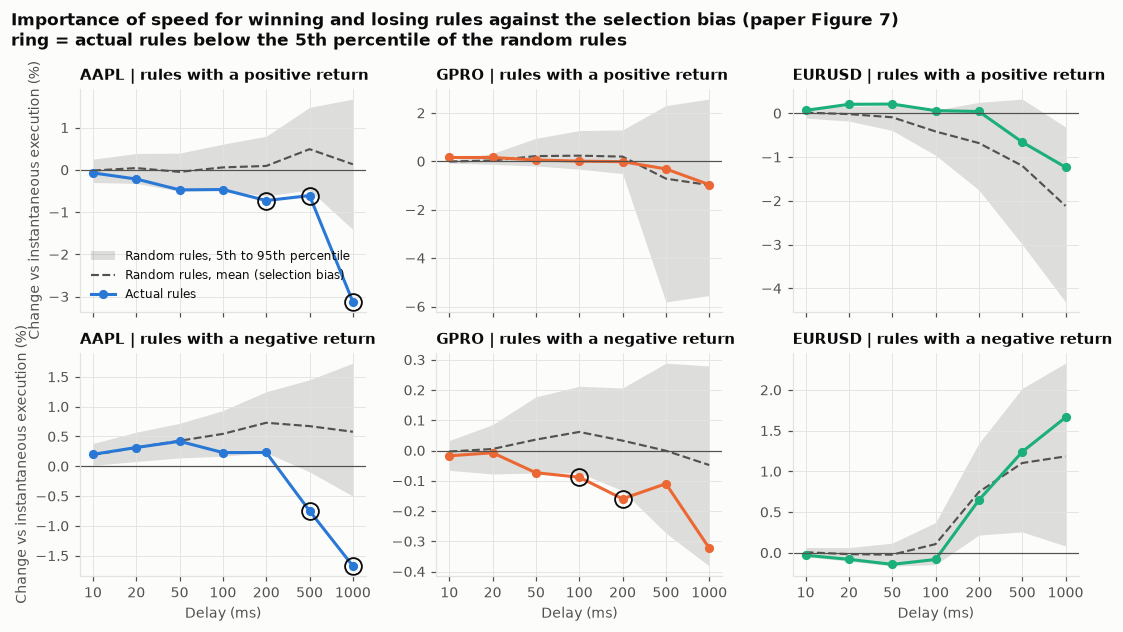

CPU times: user 1min 36s, sys: 1.87 s, total: 1min 38s
Wall time: 1min 38s


In [14]:
%%time
pl = speed.placebo(run, n_draws=5000, seed=0)
pl.to_csv(OUT / "table4b_selection_bias.csv", index=False)
fig, axes = plt.subplots(2, 3, figsize=(10, 5.8), sharex=True)
for i, sub in enumerate(("positive", "negative")):
    for j, a in enumerate(ASSETS):
        ax, x = axes[i, j], pl[(pl.asset == a) & (pl.subset == sub)]
        pos = np.arange(len(x))
        ax.fill_between(pos, x.bias_lo_pct, x.bias_hi_pct, color=MUTED, alpha=0.18, lw=0, label="Random rules, 5th to 95th percentile")
        ax.plot(pos, x.bias_pct, color=MUTED, lw=1.4, ls="--", label="Random rules, mean (selection bias)")
        ax.plot(pos, x.actual_pct, color=ASSET_COLOR[a], marker="o", ms=5, label="Actual rules")
        sig = (x.p_below < 0.05).to_numpy()
        ax.plot(pos[sig], x.actual_pct.to_numpy()[sig], **RING)
        ax.axhline(0, color=MUTED, lw=0.8)
        ax.set_xticks(pos); ax.set_xticklabels(x.delay_ms)
        ax.set_title(f"{a} | rules with a {sub} return", loc="left")
        if i == 1: ax.set_xlabel("Delay (ms)")
        if j == 0: ax.set_ylabel("Change vs instantaneous execution (%)")
axes[0, 0].legend(loc="lower left", fontsize=8)
fig.suptitle("Importance of speed for winning and losing rules against the selection bias (paper Figure 7)\nring = actual rules below the 5th percentile of the random rules", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "05_importance_of_speed_selection_bias.png"); plt.show()
pl[pl.delay_ms.isin([100, 200, 500, 1000])].set_index(["subset", "asset", "delay_ms"])[
    ["actual_pct", "bias_pct", "bias_lo_pct", "bias_hi_pct", "p_below"]].style.format("{:,.3f}")

**Reading the selection-bias test.**

- **AAPL, winning rules: speed matters.** Delay lowers the return of profitable rules by 0.5% at 100 ms, 0.7% at 200 ms and 3.1% at 1 second. Random rules lose nothing (+0.1% at 1 second, band -1.4% to +1.7%), so this is not a selection effect: p = 0.06 at 100 ms, 0.03 at 200 ms and at 500 ms, below 0.001 at 1 second. This is the paper's main result, with the same threshold of about 200 ms.
- **AAPL, losing rules.** Up to 200 ms they behave like random rules. At 500 ms and 1 second they lose more (-1.7% at 1 second against +0.6% for random rules, p < 0.001). The paper finds no effect of speed on losing rules; on AAPL a 1 second delay hurts whatever the rule's result.
- **GPRO, winning rules: no evidence.** The -1.0% at 1 second equals the selection bias (-1.0%, band -5.5% to +2.6%). Only 67 rules a day make money on GPRO, 12% of those that trade, so the band is wide. Losing rules lose slightly more than random ones at 100 and 200 ms (-0.09% and -0.16%, p = 0.03).
- **EUR/USD: the raw numbers are selection.** Winning rules lose 1.2% at 1 second, but random rules lose 2.1% (band -4.3% to -0.3%). Losing rules gain 1.7%, and random ones gain 1.2%. Neither is evidence of an effect of speed.

Without the placebo we would have concluded that delay hurts winning rules on all three assets. Beyond selection, it only does on the liquid stock.

### Effect of the delay per order

The split above conditions on performance. The following measure does not. For every order of every rule, the effect of executing it $h$ later is

$$e_h = -\,\delta\;\frac{p_{t+h} - p_t}{p_t},$$

with $\delta = +1$ and $p$ the ask for a buy, $\delta = -1$ and $p$ the bid for a sell. It is negative when the price moves in the direction of the order during the delay. Summed over the orders of a strategy it is that strategy's cost of delay, so this is the same quantity measured order by order.

Pooling the 601 rules gives 9,000 to 120,000 orders per family and asset. The 90% intervals resample trading days, which preserves the dependence between rules that trade at the same instant. The figure extends the horizon to 60 seconds to show where the price goes after the order.

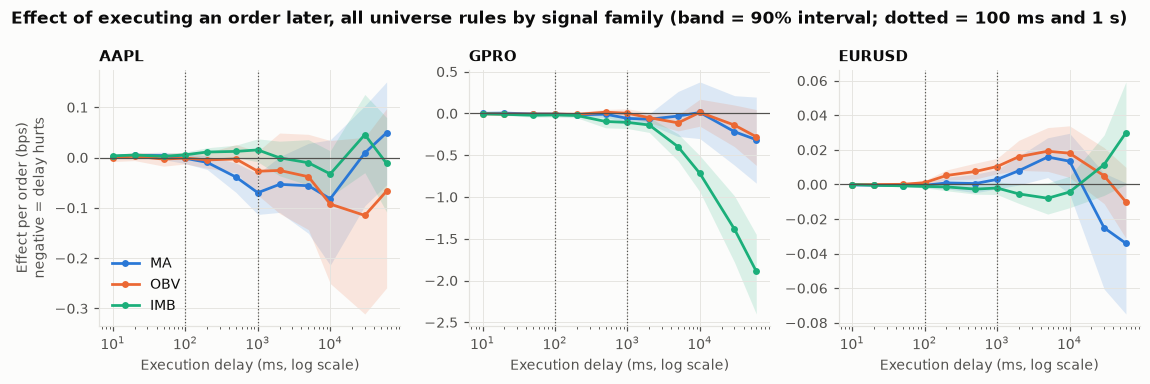

In [15]:
ou = speed.order_effect_table(run, "universe").merge(speed.family_table(run), on=["asset", "family"])
ou.to_csv(OUT / "table4c_effect_per_order_universe.csv", index=False)
rc = speed.response_curve(run)
rc.to_csv(OUT / "table4d_order_response_curve.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5))
for ax, a in zip(axes, ASSETS):
    for s in SIGNALS:
        x = rc[(rc.asset == a) & (rc.family == s)]
        ax.fill_between(x.horizon_ms, x.ci_lo, x.ci_hi, color=SIGNAL_COLOR[s], alpha=0.15, lw=0)
        ax.plot(x.horizon_ms, x.effect_bps, color=SIGNAL_COLOR[s], lw=1.8, marker="o", ms=3.5, label=s)
    for v in (100, 1000):
        ax.axvline(v, color=MUTED, lw=0.8, ls=":")
    ax.axhline(0, color=MUTED, lw=0.8); ax.set_xscale("log"); ax.set_xlabel("Execution delay (ms, log scale)")
    ax.set_title(a, loc="left")
axes[0].set_ylabel("Effect per order (bps)\nnegative = delay hurts"); axes[0].legend(loc="lower left")
fig.suptitle("Effect of executing an order later, all universe rules by signal family (band = 90% interval; dotted = 100 ms and 1 s)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "06_order_response_curve.png"); plt.show()
ou.rename(columns={**ORDER_COLS, "rules": "Rules", "ret0_bps": "Return 0 ms (bps / rule-day)", "cost1000_bps": "Cost 1 s (bps / rule-day)",
                   "cost100_bps": "Cost 100 ms (bps / rule-day)"}).set_index(["Asset", "Signal", "Delay (ms)"])[
    ["Rules", "Orders", "Effect per order (bps)", "90% CI low", "90% CI high", "p (two-sided)", "Return 0 ms (bps / rule-day)"]
].style.format("{:,.4f}").format("{:,.0f}", subset=["Rules", "Orders"]).format("{:,.1f}", subset=["Return 0 ms (bps / rule-day)"])

**Reading the per-order results.**

- **100 ms costs nothing measurable.** Every family on every asset is within 0.02 bps per order, and only one interval excludes zero (EUR/USD IMB, -0.001 bps).
- **1 second has a cost on the two stocks**: 0.07 bps per order for MA rules on AAPL (interval -0.11 to -0.03), 0.06 bps for MA rules on GPRO (-0.11 to -0.01) and 0.11 bps for IMB rules on GPRO (-0.18 to -0.04).
- **The cost is the signal's short-run predictive power.** After an IMB order on GPRO the price keeps moving in the order's direction: 0.4 bps after 5 seconds, 1.9 bps after 60 seconds. The signal predicts the next minute, and each second of delay gives up a slice of that move. On AAPL the drift after MA orders builds up over the first second (0.04 bps at 500 ms, 0.07 at 1 second) and is gone after 30 seconds.
- **On EUR/USD delay helps OBV rules**, by 0.01 bps per order at 1 second (interval 0.006 to 0.015): the price moves back after their orders. The amount is 4% of the spread.
- **Relative to the spread the cost is small.** 0.07 bps is 19% of AAPL's half-spread; 0.11 bps is 1% of GPRO's.

### Comparison with the paper

Importance of speed for rules with a positive return, 60-second signals. The paper's figures are those of Table B.1 of its internet appendix: SPY, QQQQ and IWM, 186 days of 2009, 27,424 rules, orders of 100 shares. A star marks a loss that is significant against the selection bias.

In [16]:
paper = pd.DataFrame({"SPY": [-0.0657, -0.2213, -0.3942, -1.0481], "QQQQ": [-0.0729, -0.2635, -1.0090, -1.9107],
                      "IWM": [-0.0739, -0.1493, -0.6242, -1.3355]}, index=[100, 200, 500, 1000])
paper_sig = pd.DataFrame({"SPY": [False, True, True, True], "QQQQ": [False, False, True, True],
                          "IWM": [False, False, True, True]}, index=paper.index)
ours = pl[pl.subset == "positive"].pivot(index="delay_ms", columns="asset", values="actual_pct").loc[paper.index, ASSETS]
ours_sig = pl[pl.subset == "positive"].pivot(index="delay_ms", columns="asset", values="p_below").loc[paper.index, ASSETS] < 0.05
star = lambda v, s: v.round(2).astype(str) + np.where(s, "*", "")
cmp = pd.concat({"Paper, Jan-Sep 2009 (Table B.1, 60 s)": star(paper, paper_sig), "This project, Sep 2019": star(ours, ours_sig)}, axis=1)
cmp.index.name = "Delay (ms)"
flat = cmp.copy(); flat.columns = [f"{'Paper' if 'Paper' in top else 'Ours'} {name}" for top, name in cmp.columns]
flat.to_csv(OUT / "table4e_comparison_with_paper.csv")
print("Importance of speed (%) for rules with a positive return; * = significant against the selection bias (5%, one-sided)")
cmp

Importance of speed (%) for rules with a positive return; * = significant against the selection bias (5%, one-sided)


Paper, Jan-Sep 2009 (Table B.1, 60 s)                  \
                                             SPY    QQQQ     IWM   
Delay (ms)                                                         
100                                        -0.07   -0.07   -0.07   
200                                       -0.22*   -0.26   -0.15   
500                                       -0.39*  -1.01*  -0.62*   
1000                                      -1.05*  -1.91*  -1.34*   

           This project, Sep 2019                
                             AAPL   GPRO EURUSD  
Delay (ms)                                       
100                         -0.46   0.01   0.06  
200                        -0.73*  -0.01   0.04  
500                        -0.61*  -0.31  -0.66  
1000                       -3.13*  -0.96  -1.23

**Reading the comparison.** The liquid stock reproduces the paper: no significant effect at 100 ms, a significant loss from 200 ms, and a loss at 1 second (-3.1%) of the same order as the paper's ETFs (-1.0% to -1.9%), somewhat larger. Ten years later, and on a single stock instead of an index ETF, the importance of speed has the same shape. The less liquid stock and the currency pair show losses of a similar size at 1 second (-1.0% and -1.2%), which 20 days cannot separate from the selection bias.

## 6. Do signals behave differently across market conditions?

Days are split, asset by asset, into the 10 most and 10 least volatile (one-minute mid-quote volatility). The first table is by asset: costs are in bps per rule-day over the universe (negative = delay hurts), and *abs effect* is the mean absolute change in return from a 1 second delay per round trip, which measures sensitivity regardless of sign. The second table crosses signal family and regime.

In [17]:
daily = speed.daily_universe(run)
daily.to_csv(OUT / "daily_cost_and_microstructure.csv", index=False)
cond = daily.groupby(["asset", "vol_regime"], sort=False).agg(
    days=("ret0_bps", "size"), vol_1min_bps=("vol_1min_bps", "mean"), spread_bps=("spread_bps", "mean"),
    quote_changes_per_s=("quote_moves_per_s", "mean"), ret0_bps_per_day=("ret0_bps", "mean"),
    cost100_bps_per_day=("cost100_bps", "mean"), cost1000_bps_per_day=("cost1000_bps", "mean"),
    abs_effect_1s_bps_per_trip=("abs1000_bps", "mean")).reindex(ASSETS, level=0)
cond.to_csv(OUT / "table5_volatility_regimes.csv")
cond.style.format("{:,.3f}")

In [18]:
rs = speed.regime_by_signal(run, daily)
rs.to_csv(OUT / "table5b_signal_by_volatility_regime.csv", index=False)
rs.rename(columns={"asset": "Asset", "family": "Signal", "vol_regime": "Regime", "rule_days": "Rule-days", "ret0_bps": "Return 0 ms (bps / rule-day)",
                   "cost1000_bps": "Cost 1 s (bps / rule-day)", "effect_per_order_1s_bps": "Effect per order, 1 s (bps)"}
          ).set_index(["Asset", "Signal", "Regime"])[["Rule-days", "Return 0 ms (bps / rule-day)", "Cost 1 s (bps / rule-day)",
                                                       "Effect per order, 1 s (bps)"]].style.format("{:,.3f}").format("{:,.0f}", subset=["Rule-days"])

**Performance and volatility.**

- **Delay costs on volatile days.** A 1 second delay costs 1.7 bps per rule-day on AAPL's volatile days and nothing on quiet days (+0.1). On GPRO it costs 2.0 bps on volatile days, against a small gain on quiet days (+0.3). EUR/USD is slightly positive in both regimes.
- **Sensitivity to delay rises with volatility on all three assets.** The absolute effect of a 1 second delay per round trip is 0.47 bps against 0.28 on AAPL, 0.59 against 0.25 on GPRO, 0.08 against 0.05 on EUR/USD. The quote moves further during the delay when the market moves faster.
- **Which signals.** MA rules carry the cost on both stocks, and only on volatile days: -0.11 bps per order on AAPL (-0.02 on quiet days), -0.14 on GPRO (+0.03 on quiet days). IMB on GPRO loses 0.17 bps per order on volatile days against 0.03 on quiet days. OBV on AAPL goes from -0.08 to +0.03. OBV on GPRO shows nothing in either regime.
- **Performance itself.** MA rules on AAPL lose more on volatile days (-27 against -19 bps per rule-day): the band is crossed more often and reversed more often. IMB on AAPL loses less on volatile days (-10 against -18). IMB on GPRO loses more (-518 against -406): it trades more and pays the spread each time.
- **Against the paper.** The paper finds that speed matters more on low-volatility days for SPY. Here the cost of delay is concentrated on high-volatility days.

## 7. Tick frequency and the importance of delay

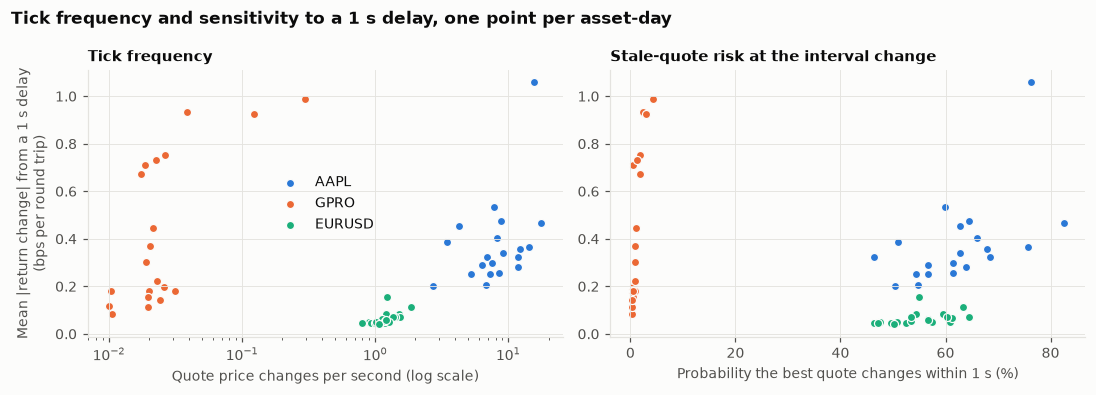

asset,AAPL,GPRO,EURUSD
quote_moves_per_s,8.7970,0.0399,1.2063
p_quote_change_100ms,0.2555,0.0023,0.1496
p_quote_change_1000ms,0.6218,0.0113,0.5503
abs_mid_move_100ms_bps,0.1117,0.0444,0.0122
abs_mid_move_1000ms_bps,0.4804,0.2370,0.0839
spread_bps,0.7335,22.5184,0.2703
abs100_bps,0.1217,0.0780,0.0150
abs1000_bps,0.3763,0.4206,0.0660
cost100_bps,0.0038,-0.1606,0.0092
cost1000_bps,-0.7745,-0.8565,0.1739


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for a in ASSETS:
    x = daily[daily.asset == a]
    axes[0].scatter(x.quote_moves_per_s, x.abs1000_bps, s=28, color=ASSET_COLOR[a], edgecolor="#fcfcfb", lw=0.8, label=a)
    axes[1].scatter(x.p_quote_change_1000ms * 100, x.abs1000_bps, s=28, color=ASSET_COLOR[a], edgecolor="#fcfcfb", lw=0.8, label=a)
axes[0].set_xscale("log"); axes[0].set_xlabel("Quote price changes per second (log scale)")
axes[1].set_xlabel("Probability the best quote changes within 1 s (%)")
axes[0].set_ylabel("Mean |return change| from a 1 s delay\n(bps per round trip)")
axes[0].set_title("Tick frequency", loc="left"); axes[1].set_title("Stale-quote risk at the interval change", loc="left")
axes[0].legend()
fig.suptitle("Tick frequency and sensitivity to a 1 s delay, one point per asset-day", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "07_tick_frequency_vs_delay_sensitivity.png"); plt.show()

tick = daily.groupby("asset", sort=False)[["quote_moves_per_s", "p_quote_change_100ms", "p_quote_change_1000ms", "abs_mid_move_100ms_bps",
        "abs_mid_move_1000ms_bps", "spread_bps", "abs100_bps", "abs1000_bps", "cost100_bps", "cost1000_bps"]].mean().reindex(ASSETS)
tick["|mid move| 1 s / half-spread"] = tick.abs_mid_move_1000ms_bps / (tick.spread_bps / 2)
corr = daily.groupby("asset", sort=False)[["abs1000_bps", "quote_moves_per_s", "vol_1min_bps"]].corr().xs("abs1000_bps", level=1)
tick["corr(sensitivity, quote changes)"], tick["corr(sensitivity, volatility)"] = corr.quote_moves_per_s, corr.vol_1min_bps
tick.to_csv(OUT / "table7_tick_frequency_and_delay.csv")
tick.T.style.format("{:,.4f}")

**Does tick frequency drive the importance of delay?** Partly, and the table shows why it is not the whole story.

- **Tick frequency sets the probability of a stale quote.** After 100 ms the best quote has changed 26% of the time on AAPL, 15% on EUR/USD and 0.2% on GPRO; after 1 second, 62%, 55% and 1.1%.
- **At 100 ms the fast book is the most exposed**: the absolute effect per round trip is 0.12 bps on AAPL, against 0.08 on GPRO and under 0.02 on EUR/USD.
- **Tick size relative to price sets the cost of each miss.** When GPRO's quote moves it moves by a full cent, 22 bps. AAPL's cent is 0.5 bp and an EUR/USD pip fraction is under 0.1 bp. So at 1 second GPRO, the slowest book by a factor of 200, is as sensitive per round trip as AAPL (0.42 against 0.38 bps), and EUR/USD is far behind (0.07 bps) although it ticks 30 times faster than GPRO.
- **Within an asset, busier days are more delay-sensitive.** The correlation of daily sensitivity with the number of quote changes per second is 0.48 on AAPL, 0.57 on GPRO and 0.55 on EUR/USD; with volatility it is 0.48, 0.69 and 0.67.
- **What matters for a strategy is the expected move against the half-spread.** After 1 second the mid has moved on average 1.3 half-spreads on AAPL, 0.6 on EUR/USD and 0.02 on GPRO.

**How we would factor this into a trading strategy.**

1. *Budget latency per asset in units of expected quote move, not in milliseconds.* The relevant number is P(quote changes during the delay) x size of a tick in bps, compared with the signal's expected edge. On AAPL a quarter of the quotes have changed after 100 ms and the measured cost starts around 200 ms; on GPRO 100 ms is free.
2. *Match the signal's horizon to the achievable latency.* IMB on GPRO pays out over a minute, so a 1 second delay gives up about 6% of its move (0.11 of 1.9 bps). The drift after MA orders on AAPL is over within a second: that edge exists only for a sub-second trader.
3. *In large-tick, slow books, do not cross the spread.* GPRO's signals predict about 2 bps and a round trip costs 22.5 bps. The same signals should be expressed with passive orders: queue position then replaces latency as the scarce resource.
4. *Do not pay for speed on a signal that loses.* Beyond selection, the cost of delay falls on AAPL's profitable rules. Speed is valuable once the signal predicts the next move; otherwise it just delivers the wrong trade sooner.
5. *Scale speed requirements with volatility.* The cost of a 1 second delay is concentrated on volatile days for both stocks; wider bandwidths or standing aside around scheduled events limit the exposure when the infrastructure cannot be faster.

## 8. Limits

- **One month.** Single-strategy costs of delay cannot be measured, and the pooled results rest on 20 days. With seven delays, three assets and two groups of rules, a few rejections at the 5% level are expected by chance; the AAPL results at 1 second (p < 0.001) do not depend on that.
- **Fill at the best quote.** The $1,000,000 order is 22 and 53 times the displayed size on the two stocks. True costs, and the cost of arriving after others have taken the best level, are understated there.
- **EUR/USD.** One venue's quotes, tick volume in place of traded volume, New York hours only.
- **Nasdaq quotes only.** The consolidated best bid and offer may be tighter than the Nasdaq book for AAPL (1.6 cents on average here). GPRO is already at the one-cent minimum.
- **Start of the day.** Lookbacks start at the open, so rules with a 30-minute lookback trade from 10:00 and those with a 60-minute lookback from 10:30.
- **No fees or rebates**, as in the paper.